# LOCA-PRAM — Negative-sample evaluation (downsampled pipeline)

Mirror of the real-image inference path from `LOCA_PRAM_main_downsampled.ipynb`
(REAL DATA TEST section), applied to negative assay images to characterize
false-positive behavior.

**Pipeline match.** Same `DOWNSCALE_FACTOR`, `MARKER_THRESHOLD`, marker
buffer, edge margin, `normalize_tile`, `compute_forbidden_mask_fast`, and
`detect_via_cv2` as the production path. Each native FOV is tiled at
`NATIVE_WINDOW = (256, 256)`; tiles are downsampled to 128, normalized over
valid (non-marker) pixels, run through the model, and detections inside the
forbidden mask are dropped.

**Default threshold** = `0.004` (best F1 on real-data validation; see
`LOCA_PRAM_main_downsampled.ipynb` real-data sweep).

**Sweep** = `(0.001, 0.002, 0.003, 0.004, 0.006, 0.008, 0.01, 0.02, 0.03, 0.05,
0.07, 0.10, 0.15, 0.25)` — same list as `sweep_real(...)` in the downsampled
notebook. Each image runs through the model once and counts are recomputed at
every threshold from the cached `p_map` + forbidden mask.

**Sampling.** `IMAGES_PER_DEMO = 3` random tiles per `demo_XXXX/`. Set to
`None` to run every image.

**Outputs.**
- `negative_eval_results.csv` — one row per (image, threshold).
- `negative_eval_summary.png` — distribution at default threshold + sweep curve.


## 1. Imports

In [1]:
import os
import glob
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

Image.MAX_IMAGE_PIXELS = None


C:\Users\hankeun2\Desktop\brian_test\pram_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Model architecture

Self-contained copy of the `GaussianMixtureModel` from `LOCA_PRAM_main_downsampled.ipynb` so this notebook runs standalone.

In [43]:
class conv_block(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1, norm_groups=6, dilation=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, dilation, dilation=dilation, bias=True),
            nn.GroupNorm(norm_groups, out_channels),
            nn.ELU(),
            nn.Conv2d(out_channels, out_channels, 3, 1, dilation, dilation=dilation, bias=True),
            nn.GroupNorm(norm_groups, out_channels),
            nn.ELU(),
        )
    def forward(self, x): return self.conv(x)


class up_conv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1, norm_groups=6):
        super().__init__()
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True),
            nn.Conv2d(in_channels, out_channels, 3, 1, padding="same", bias=True),
        )
    def forward(self, x): return self.up(x)


class multi_head(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1, norm_groups=6):
        super().__init__()
        self.multi_head = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, 3, 1, padding="same", bias=True),
            nn.GroupNorm(norm_groups, in_channels),
            nn.ELU(),
            nn.Conv2d(in_channels, out_channels, 1, 1, padding="same", bias=True),
        )
    def forward(self, x): return self.multi_head(x)


class GaussianMixtureModel(nn.Module):
    def __init__(self, num_channels):
        super().__init__()
        self.out_channels_heads = (1, 3, 3, 1)
        self.num_channels = num_channels

        self.Conv1 = conv_block(num_channels, 36, norm_groups=6)
        self.Maxpool1 = nn.MaxPool2d(2, 2)
        self.Conv2 = conv_block(36, 72, norm_groups=6)
        self.Maxpool2 = nn.MaxPool2d(2, 2)
        self.Conv3 = conv_block(72, 144, norm_groups=6)
        self.Maxpool3 = nn.MaxPool2d(2, 2)
        self.Conv4 = nn.Sequential(
            conv_block(144, 288, norm_groups=6, dilation=4),
            conv_block(288, 288, norm_groups=6, dilation=8),
        )
        self.Up3 = up_conv(288, 144, norm_groups=6)
        self.Up_conv3 = conv_block(288, 144, norm_groups=6)
        self.Up2 = up_conv(144, 72, norm_groups=6)
        self.Up_conv2 = conv_block(144, 72, norm_groups=6)
        self.Up1 = up_conv(72, 36, norm_groups=6)
        self.Up_conv1 = conv_block(72, 36, norm_groups=6)
        self.dropout = nn.Dropout2d(p=0.3)
        self.sigma_eps = 0.001
        self.mt_heads = nn.ModuleList([
            multi_head(36, ch, norm_groups=6) for ch in self.out_channels_heads
        ])
        self.initialize_weights()
        nn.init.constant_(self.mt_heads[0].multi_head[-1].bias, -6.0)
        nn.init.zeros_(self.mt_heads[0].multi_head[-1].weight)

    def initialize_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None: nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.GroupNorm):
                nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)

    def forward(self, x, training=False):
        x1 = self.Conv1(x)
        x2 = self.Conv2(self.Maxpool1(x1))
        x3 = self.Conv3(self.Maxpool2(x2))
        x4 = self.Conv4(self.Maxpool3(x3))
        d3 = self.Up3(x4); d3 = torch.cat((x3, d3), dim=1); d3 = self.Up_conv3(d3)
        d2 = self.Up2(d3); d2 = torch.cat((x2, d2), dim=1); d2 = self.Up_conv2(d2)
        d1 = self.Up1(d2); d1 = torch.cat((x1, d1), dim=1); d1 = self.Up_conv1(d1)
        d = [h(d1) for h in self.mt_heads]
        p = torch.sigmoid(torch.clamp(d[0], min=-20.0, max=20.0))
        pxyn_mean = d[1]
        pxyn_mean[:, [0, 1], ...] = torch.tanh(pxyn_mean[:, [0, 1], ...])
        pxyn_mean[:, [2], ...] = torch.sigmoid(pxyn_mean[:, [2], ...]) * 100
        pxy_std = torch.sigmoid(d[2]) * 50 + self.sigma_eps
        bg = d[3]
        return p, pxyn_mean, pxy_std, bg


## 3. Config

All knobs match the downsampled notebook's real-data section. Edit only if your training/test config drifts.

In [45]:
# --- pipeline scales (must match training/inference notebook) ---
DOWNSCALE_FACTOR = 2
BASE_WINDOW_SIZE = (256, 256)
window_size = (BASE_WINDOW_SIZE[0] // DOWNSCALE_FACTOR,
                BASE_WINDOW_SIZE[1] // DOWNSCALE_FACTOR)        # (128, 128)
NATIVE_WINDOW = (window_size[0] * DOWNSCALE_FACTOR,
                  window_size[1] * DOWNSCALE_FACTOR)             # (256, 256)

# --- marker / forbidden-mask config (matches downsampled nb) ---
MARKER_THRESHOLD = 15

BASE_SIGMA_X_LOC = 9.79
BASE_SIGMA_Y_LOC = 7.88
BASE_MARGIN      = 12
SIGMA_X_LOC = BASE_SIGMA_X_LOC / DOWNSCALE_FACTOR
SIGMA_Y_LOC = BASE_SIGMA_Y_LOC / DOWNSCALE_FACTOR
MARGIN      = max(1, int(round(BASE_MARGIN / DOWNSCALE_FACTOR)))
BUFFER_SIGMA_MULT = 5.0
BUFFER_PX = int(round(BUFFER_SIGMA_MULT * max(SIGMA_X_LOC, SIGMA_Y_LOC)))

# real-data validation in the downsampled nb uses a bigger edge exclusion than training
EDGE_MARGIN_TEST = 6

# --- detector / threshold ---
MIN_AREA          = 1
DEFAULT_THRESHOLD = 0.004     # best F1 on real-data sweep
SWEEP_THRESHOLDS  = (0.001, 0.002, 0.003, 0.004, 0.006, 0.008,
                      0.01,  0.02,  0.03,  0.05,  0.07,  0.10,
                      0.15,  0.25)
ALL_THRESHOLDS = sorted(set(list(SWEEP_THRESHOLDS) + [DEFAULT_THRESHOLD]))

# --- I/O ---
ASSAYS_GLOB     = "assays/*pos*"#"assays/*neg*"
DEMO_GLOB       = "demo_*"
IMAGE_EXT       = ".jpg"
IMAGES_PER_DEMO = 10                   # None -> every image
RANDOM_SEED     = 0

MODEL_PATH   = "pram_dense.pth"
RESULTS_CSV  = "positive_eval_results.csv"
SUMMARY_PNG  = "positive_eval_summary.png"

print(f"window_size      = {window_size}")
print(f"NATIVE_WINDOW    = {NATIVE_WINDOW}")
print(f"BUFFER_PX        = {BUFFER_PX}, MARGIN = {MARGIN}, "
      f"EDGE_MARGIN_TEST = {EDGE_MARGIN_TEST}")
print(f"DEFAULT_THRESHOLD = {DEFAULT_THRESHOLD}")
print(f"sweep            = {SWEEP_THRESHOLDS}")


window_size      = (128, 128)
NATIVE_WINDOW    = (256, 256)
BUFFER_PX        = 24, MARGIN = 6, EDGE_MARGIN_TEST = 6
DEFAULT_THRESHOLD = 0.004
sweep            = (0.001, 0.002, 0.003, 0.004, 0.006, 0.008, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.15, 0.25)


## 4. Inference helpers — same as downsampled notebook

In [46]:
def load_real_native(path):
    """Red channel at full (non-downsampled) resolution."""
    arr = np.asarray(Image.open(path)).astype(np.float32)
    if arr.ndim == 3:
        arr = arr[:, :, 0]
    return arr


def downsample_image(img, factor=DOWNSCALE_FACTOR):
    if factor == 1:
        return img
    h, w = img.shape[:2]
    return cv2.resize(img, (w // factor, h // factor),
                      interpolation=cv2.INTER_AREA)


def normalize_tile(image):
    """Mean/std over non-marker pixels only (matches training preprocessing)."""
    valid = image > MARKER_THRESHOLD
    if valid.any():
        m, s = image[valid].mean(), image[valid].std()
    else:
        m, s = image.mean(), image.std()
    if s == 0:
        s = 1
    return (image - m) / s


def compute_forbidden_mask_fast(image, buffer_px=BUFFER_PX,
                                 threshold=MARKER_THRESHOLD,
                                 margin=EDGE_MARGIN_TEST):
    """Forbidden = pixels within buffer_px of any marker pixel OR within
    margin of tile edge. Matches the downsampled notebook."""
    H, W = image.shape
    non_marker = (image > threshold).astype(np.uint8)
    if non_marker.all():
        forbidden = np.zeros((H, W), dtype=bool)
    else:
        dist = cv2.distanceTransform(non_marker, cv2.DIST_L2, 3)
        forbidden = dist <= buffer_px
    if margin > 0:
        forbidden[:margin, :]  = True
        forbidden[-margin:, :] = True
        forbidden[:, :margin]  = True
        forbidden[:, -margin:] = True
    return forbidden


def detect_via_cv2(p_map_np, forbidden_mask, p_threshold,
                   min_area=MIN_AREA, connectivity=8):
    """cv2 connected components, mask-aware. Returns just the count for speed."""
    binary = ((p_map_np > p_threshold) & ~forbidden_mask).astype(np.uint8)
    n_labels, _, stats, _ = cv2.connectedComponentsWithStats(
        binary, connectivity=connectivity)
    if n_labels <= 1:
        return 0
    areas = stats[1:, cv2.CC_STAT_AREA]
    return int((areas >= min_area).sum())


## 5. Per-image inference

Tile native FOV at `NATIVE_WINDOW`, downsample each tile, run the model, cache `p_map` + forbidden mask per tile, then count at every threshold.

In [47]:
def process_image(model, device, path, thresholds=ALL_THRESHOLDS):
    """Returns a dict with per-threshold detection counts + mask stats."""
    img = load_real_native(path)
    h, w = img.shape
    n_ty = h // NATIVE_WINDOW[0]
    n_tx = w // NATIVE_WINDOW[1]
    if n_ty == 0 or n_tx == 0:
        raise ValueError(f"image too small ({h}x{w}) for NATIVE_WINDOW={NATIVE_WINDOW}")

    counts = {thr: 0 for thr in thresholds}
    total_pixels = 0
    masked_pixels = 0
    max_p = 0.0

    with torch.no_grad():
        for i in range(n_ty):
            for j in range(n_tx):
                native_tile = img[i*NATIVE_WINDOW[0]:(i+1)*NATIVE_WINDOW[0],
                                  j*NATIVE_WINDOW[1]:(j+1)*NATIVE_WINDOW[1]]
                raw = downsample_image(native_tile)        # 256 -> 128
                norm = normalize_tile(raw)
                forbidden = compute_forbidden_mask_fast(raw)

                x_in = torch.from_numpy(norm).float().unsqueeze(0).unsqueeze(0).to(device)
                p, _, _, _ = model(x_in, training=False)
                p_map = p[0, 0].cpu().numpy()

                max_p = max(max_p, float(p_map.max()))
                total_pixels  += forbidden.size
                masked_pixels += int(forbidden.sum())

                for thr in thresholds:
                    counts[thr] += detect_via_cv2(p_map, forbidden, thr)

    return {
        "counts": counts,
        "max_p": max_p,
        "n_tiles": n_ty * n_tx,
        "mask_coverage": masked_pixels / total_pixels if total_pixels else 0.0,
        "image_h": h,
        "image_w": w,
    }


## 6. Collect sampled images

In [48]:
random.seed(RANDOM_SEED)

session_dirs = sorted(glob.glob(ASSAYS_GLOB))
print(f"Sessions found: {len(session_dirs)}")
for s in session_dirs:
    print(f"  {s}")

records = []
for sess in session_dirs:
    sess_name = os.path.basename(sess)
    demo_dirs = sorted(glob.glob(os.path.join(sess, DEMO_GLOB)))
    for demo in demo_dirs:
        demo_name = os.path.basename(demo)
        imgs = sorted(glob.glob(os.path.join(demo, f"*{IMAGE_EXT}")))
        if not imgs:
            continue
        chosen = imgs if IMAGES_PER_DEMO is None else random.sample(
            imgs, min(IMAGES_PER_DEMO, len(imgs)))
        for p in chosen:
            records.append({"session": sess_name, "demo": demo_name, "path": p})

print(f"\nTotal images to process: {len(records)}")
for r in records[:5]:
    print(" ", r["session"], r["demo"], os.path.basename(r["path"]))


Sessions found: 1
  assays\2026.06.24_pos_1pM_01_(code_had_bug_some_time_points_missing)

Total images to process: 110
  2026.06.24_pos_1pM_01_(code_had_bug_some_time_points_missing) demo_0001 tile_13_13_20.57.04.jpg
  2026.06.24_pos_1pM_01_(code_had_bug_some_time_points_missing) demo_0001 tile_13_14_20.56.26.jpg
  2026.06.24_pos_1pM_01_(code_had_bug_some_time_points_missing) demo_0001 tile_11_12_20.54.07.jpg
  2026.06.24_pos_1pM_01_(code_had_bug_some_time_points_missing) demo_0001 tile_12_14_20.56.18.jpg
  2026.06.24_pos_1pM_01_(code_had_bug_some_time_points_missing) demo_0001 tile_14_12_20.56.47.jpg


## 7. Load model

In [49]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = GaussianMixtureModel(num_channels=1)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device).eval()
print(f"Loaded {MODEL_PATH} on {device}")


Loaded pram_dense.pth on cuda:0


## 8. Run batch inference

Incremental CSV save every 5 images so a crash mid-run keeps prior progress.

In [50]:
rows = []
t0 = time.time()
for i, rec in enumerate(tqdm(records, desc="images")):
    try:
        out = process_image(model, device, rec["path"])
    except Exception as e:
        print(f"!! {rec['path']}: {e}")
        continue
    for thr, n in out["counts"].items():
        rows.append({
            "session":       rec["session"],
            "demo":          rec["demo"],
            "image":         os.path.basename(rec["path"]),
            "path":          rec["path"],
            "threshold":     thr,
            "n_detections":  n,
            "max_p":         out["max_p"],
            "n_tiles":       out["n_tiles"],
            "mask_coverage": out["mask_coverage"],
            "image_h":       out["image_h"],
            "image_w":       out["image_w"],
        })
    if (i + 1) % 5 == 0 or i == len(records) - 1:
        pd.DataFrame(rows).to_csv(RESULTS_CSV, index=False)

print(f"\nDone in {time.time()-t0:.1f}s. Wrote {RESULTS_CSV} ({len(rows)} rows)")
df = pd.DataFrame(rows)
df.head()


images: 100%|████████████████████████████████████████████████████████████████████████████| 110/110 [02:17<00:00,  1.25s/it]


Done in 137.5s. Wrote positive_eval_results.csv (1540 rows)


,session,demo,image,path,threshold,n_detections,max_p,n_tiles,mask_coverage,image_h,image_w
0,2026.06.24_pos_1pM_01_(code_had_bug_some_time_...,demo_0001,tile_13_13_20.57.04.jpg,assays\2026.06.24_pos_1pM_01_(code_had_bug_som...,0.001,144,0.319889,165,0.273543,3040,4056
1,2026.06.24_pos_1pM_01_(code_had_bug_some_time_...,demo_0001,tile_13_13_20.57.04.jpg,assays\2026.06.24_pos_1pM_01_(code_had_bug_som...,0.002,128,0.319889,165,0.273543,3040,4056
2,2026.06.24_pos_1pM_01_(code_had_bug_some_time_...,demo_0001,tile_13_13_20.57.04.jpg,assays\2026.06.24_pos_1pM_01_(code_had_bug_som...,0.003,119,0.319889,165,0.273543,3040,4056
3,2026.06.24_pos_1pM_01_(code_had_bug_some_time_...,demo_0001,tile_13_13_20.57.04.jpg,assays\2026.06.24_pos_1pM_01_(code_had_bug_som...,0.004,115,0.319889,165,0.273543,3040,4056
4,2026.06.24_pos_1pM_01_(code_had_bug_some_time_...,demo_0001,tile_13_13_20.57.04.jpg,assays\2026.06.24_pos_1pM_01_(code_had_bug_som...,0.006,107,0.319889,165,0.273543,3040,4056


## 9. Summary

In [51]:
df = pd.read_csv(RESULTS_CSV)

print("=== Detections per image at each threshold ===")
print(df.groupby("threshold")["n_detections"].describe()[["count", "mean", "50%", "max"]])

print(f"\n=== At DEFAULT_THRESHOLD={DEFAULT_THRESHOLD} ===")
dfd = df[df["threshold"] == DEFAULT_THRESHOLD]
print(dfd.groupby("session")["n_detections"].describe()[["count", "mean", "50%", "max"]])

print("\n=== Worst 10 images at default threshold ===")
print(dfd.sort_values("n_detections", ascending=False)
        .head(10)[["session", "demo", "image", "n_detections", "max_p", "mask_coverage"]]
        .to_string(index=False))

print(f"\nMean mask coverage: {dfd['mask_coverage'].mean():.1%}  "
      f"(fraction of pixels excluded by marker/edge mask)")


=== Detections per image at each threshold ===
           count        mean    50%     max
threshold                                  
0.001      110.0  351.318182  317.5  1001.0
0.002      110.0  319.136364  292.5   928.0
0.003      110.0  300.963636  275.5   883.0
0.004      110.0  288.300000  259.0   856.0
0.006      110.0  269.072727  245.5   818.0
0.008      110.0  255.281818  233.0   763.0
0.010      110.0  243.990909  222.5   734.0
0.020      110.0  206.081818  181.5   639.0
0.030      110.0  180.036364  159.0   561.0
0.050      110.0  142.581818  125.0   444.0
0.070      110.0  112.909091   96.0   358.0
0.100      110.0   78.445455   62.0   260.0
0.150      110.0   37.245455   28.0   150.0
0.250      110.0    4.736364    3.0    23.0

=== At DEFAULT_THRESHOLD=0.004 ===
                                                    count   mean    50%    max
session                                                                       
2026.06.24_pos_1pM_01_(code_had_bug_some_time_p...  110

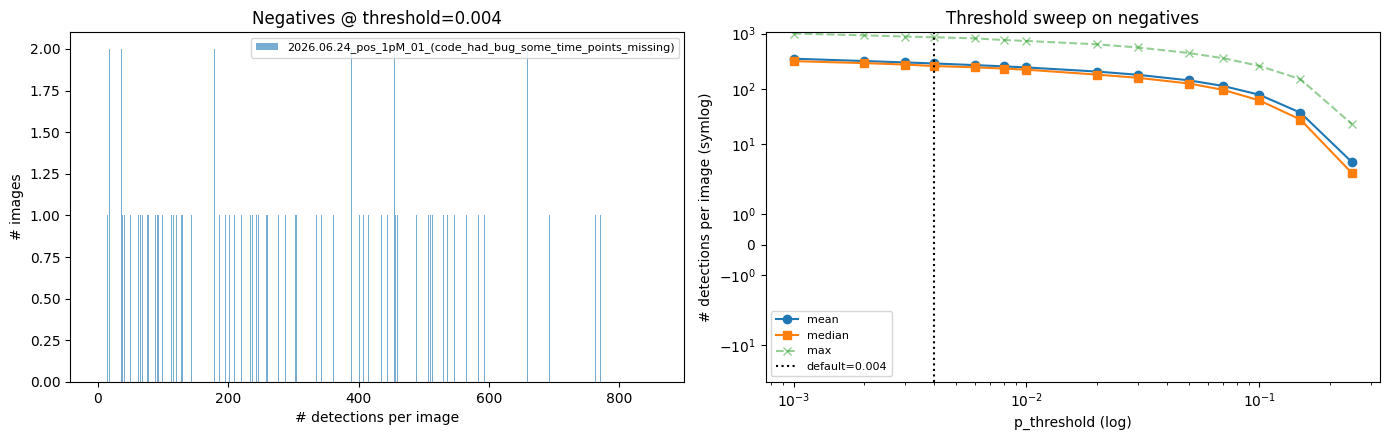

Saved positive_eval_summary.png


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

dfd = df[df["threshold"] == DEFAULT_THRESHOLD]
sessions = sorted(dfd["session"].unique())
upper = max(int(dfd["n_detections"].max()) + 2, 10)
bins = np.arange(0, upper)
for s in sessions:
    axes[0].hist(dfd[dfd["session"] == s]["n_detections"], bins=bins,
                 alpha=0.6, label=s)
axes[0].set_xlabel("# detections per image")
axes[0].set_ylabel("# images")
axes[0].set_title(f"Negatives @ threshold={DEFAULT_THRESHOLD}")
axes[0].legend(fontsize=8)

sweep = df.groupby("threshold")["n_detections"].agg(["mean", "median", "max"]).reset_index()
axes[1].plot(sweep["threshold"], sweep["mean"],   "o-",  label="mean")
axes[1].plot(sweep["threshold"], sweep["median"], "s-",  label="median")
axes[1].plot(sweep["threshold"], sweep["max"],    "x--", label="max", alpha=0.5)
axes[1].axvline(DEFAULT_THRESHOLD, color="k", ls=":", label=f"default={DEFAULT_THRESHOLD}")
axes[1].set_xscale("log")
axes[1].set_yscale("symlog")
axes[1].set_xlabel("p_threshold (log)")
axes[1].set_ylabel("# detections per image (symlog)")
axes[1].set_title("Threshold sweep on negatives")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(SUMMARY_PNG, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved {SUMMARY_PNG}")


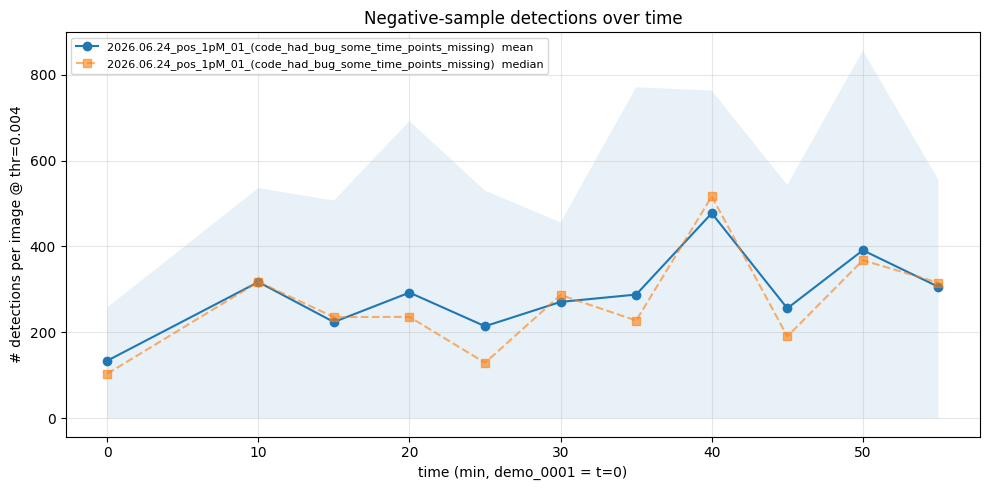

session  2026.06.24_pos_1pM_01_(code_had_bug_some_time_points_missing)
t_min                                                                 
0                                                                133.9
10                                                               317.2
15                                                               224.0
20                                                               292.6
25                                                               214.2
30                                                               270.9
35                                                               288.0
40                                                               477.4
45                                                               255.9
50                                                               391.2
55                                                               306.0


In [53]:
MINUTES_PER_CYCLE = 5

dfd = df[df["threshold"] == DEFAULT_THRESHOLD].copy()
dfd["cycle"] = dfd["demo"].str.extract(r"demo_(\d+)").astype(int)
dfd["t_min"] = (dfd["cycle"] - 1) * MINUTES_PER_CYCLE

agg = (dfd.groupby(["session", "t_min"])["n_detections"]
          .agg(["mean", "median", "max", "count"])
          .reset_index())

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
for sess in sorted(agg["session"].unique()):
    g = agg[agg["session"] == sess].sort_values("t_min")
    ax.plot(g["t_min"], g["mean"],   "o-", label=f"{sess}  mean")
    ax.plot(g["t_min"], g["median"], "s--", alpha=0.6, label=f"{sess}  median")
    ax.fill_between(g["t_min"], 0, g["max"], alpha=0.1)   # max envelope

ax.set_xlabel("time (min, demo_0001 = t=0)")
ax.set_ylabel(f"# detections per image @ thr={DEFAULT_THRESHOLD}")
ax.set_title("Negative-sample detections over time")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("negative_eval_timeseries.png", dpi=120, bbox_inches="tight")
plt.show()

# Per-cycle table for the record
print(agg.pivot_table(index="t_min", columns="session", values="mean")
         .round(2).to_string())

## 10. Inspect top offenders

With the marker mask applied, anything that still gets detected at the default threshold should be inspected. Shows the raw image with detected centroids overlaid (red) for the worst K images.

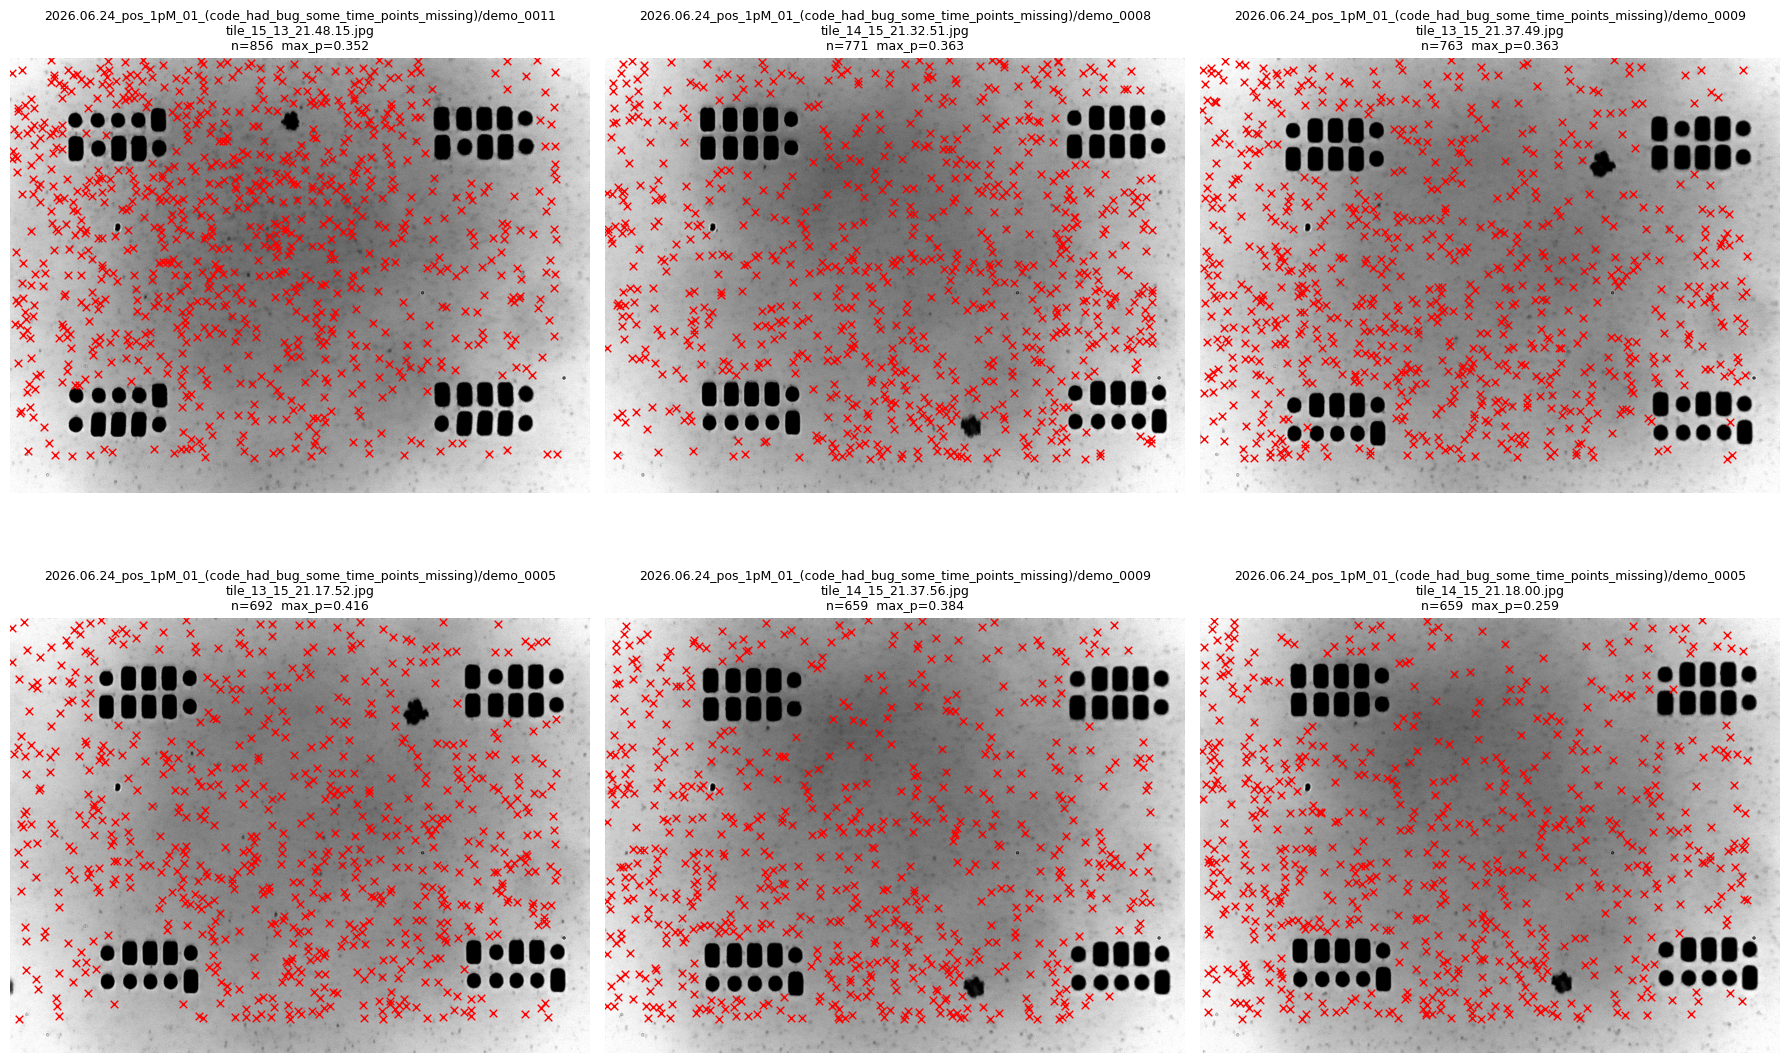

In [54]:
TOP_K = 6

dfd = df[df["threshold"] == DEFAULT_THRESHOLD].sort_values(
    "n_detections", ascending=False)
top = dfd.head(TOP_K)


def detect_for_viz(model, device, path, p_threshold=DEFAULT_THRESHOLD):
    """Re-run inference and return per-tile detections in NATIVE coordinates."""
    img = load_real_native(path)
    h, w = img.shape
    n_ty = h // NATIVE_WINDOW[0]; n_tx = w // NATIVE_WINDOW[1]
    pts_x, pts_y = [], []
    with torch.no_grad():
        for i in range(n_ty):
            for j in range(n_tx):
                native_tile = img[i*NATIVE_WINDOW[0]:(i+1)*NATIVE_WINDOW[0],
                                  j*NATIVE_WINDOW[1]:(j+1)*NATIVE_WINDOW[1]]
                raw = downsample_image(native_tile)
                norm = normalize_tile(raw)
                forbidden = compute_forbidden_mask_fast(raw)
                x_in = torch.from_numpy(norm).float().unsqueeze(0).unsqueeze(0).to(device)
                p, _, _, _ = model(x_in, training=False)
                p_map = p[0, 0].cpu().numpy()
                binary = ((p_map > p_threshold) & ~forbidden).astype(np.uint8)
                n_labels, _, _, centroids = cv2.connectedComponentsWithStats(binary, 8)
                if n_labels > 1:
                    cx128 = centroids[1:, 0]; cy128 = centroids[1:, 1]
                    pts_x.append(cx128 * DOWNSCALE_FACTOR + j * NATIVE_WINDOW[1])
                    pts_y.append(cy128 * DOWNSCALE_FACTOR + i * NATIVE_WINDOW[0])
    if pts_x:
        return img, np.concatenate(pts_x), np.concatenate(pts_y)
    return img, np.array([]), np.array([])


if len(top) == 0 or top["n_detections"].max() == 0:
    print("No detections at default threshold — nothing to inspect.")
else:
    cols = 3; rows = (len(top) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 6*rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (_, row) in zip(axes, top.iterrows()):
        try:
            img, cx, cy = detect_for_viz(model, device, row["path"])
            ax.imshow(img, cmap="gray", vmin=np.percentile(img, 1),
                                            vmax=np.percentile(img, 99))
            if len(cx):
                ax.scatter(cx, cy, marker="x", color="red", s=30, lw=1)
            ax.set_title(f"{row['session']}/{row['demo']}\n{row['image']}\n"
                         f"n={int(row['n_detections'])}  max_p={row['max_p']:.3f}",
                         fontsize=9)
        except Exception as e:
            ax.set_title(f"load failed: {e}", fontsize=8)
        ax.axis("off")
    for ax in axes[len(top):]: ax.axis("off")
    plt.tight_layout()
    plt.show()


assays\2026.06.24_pos_1pM_01_(code_had_bug_some_time_points_missing)\demo_0011\tile_15_13_21.48.15.jpg total n= 856


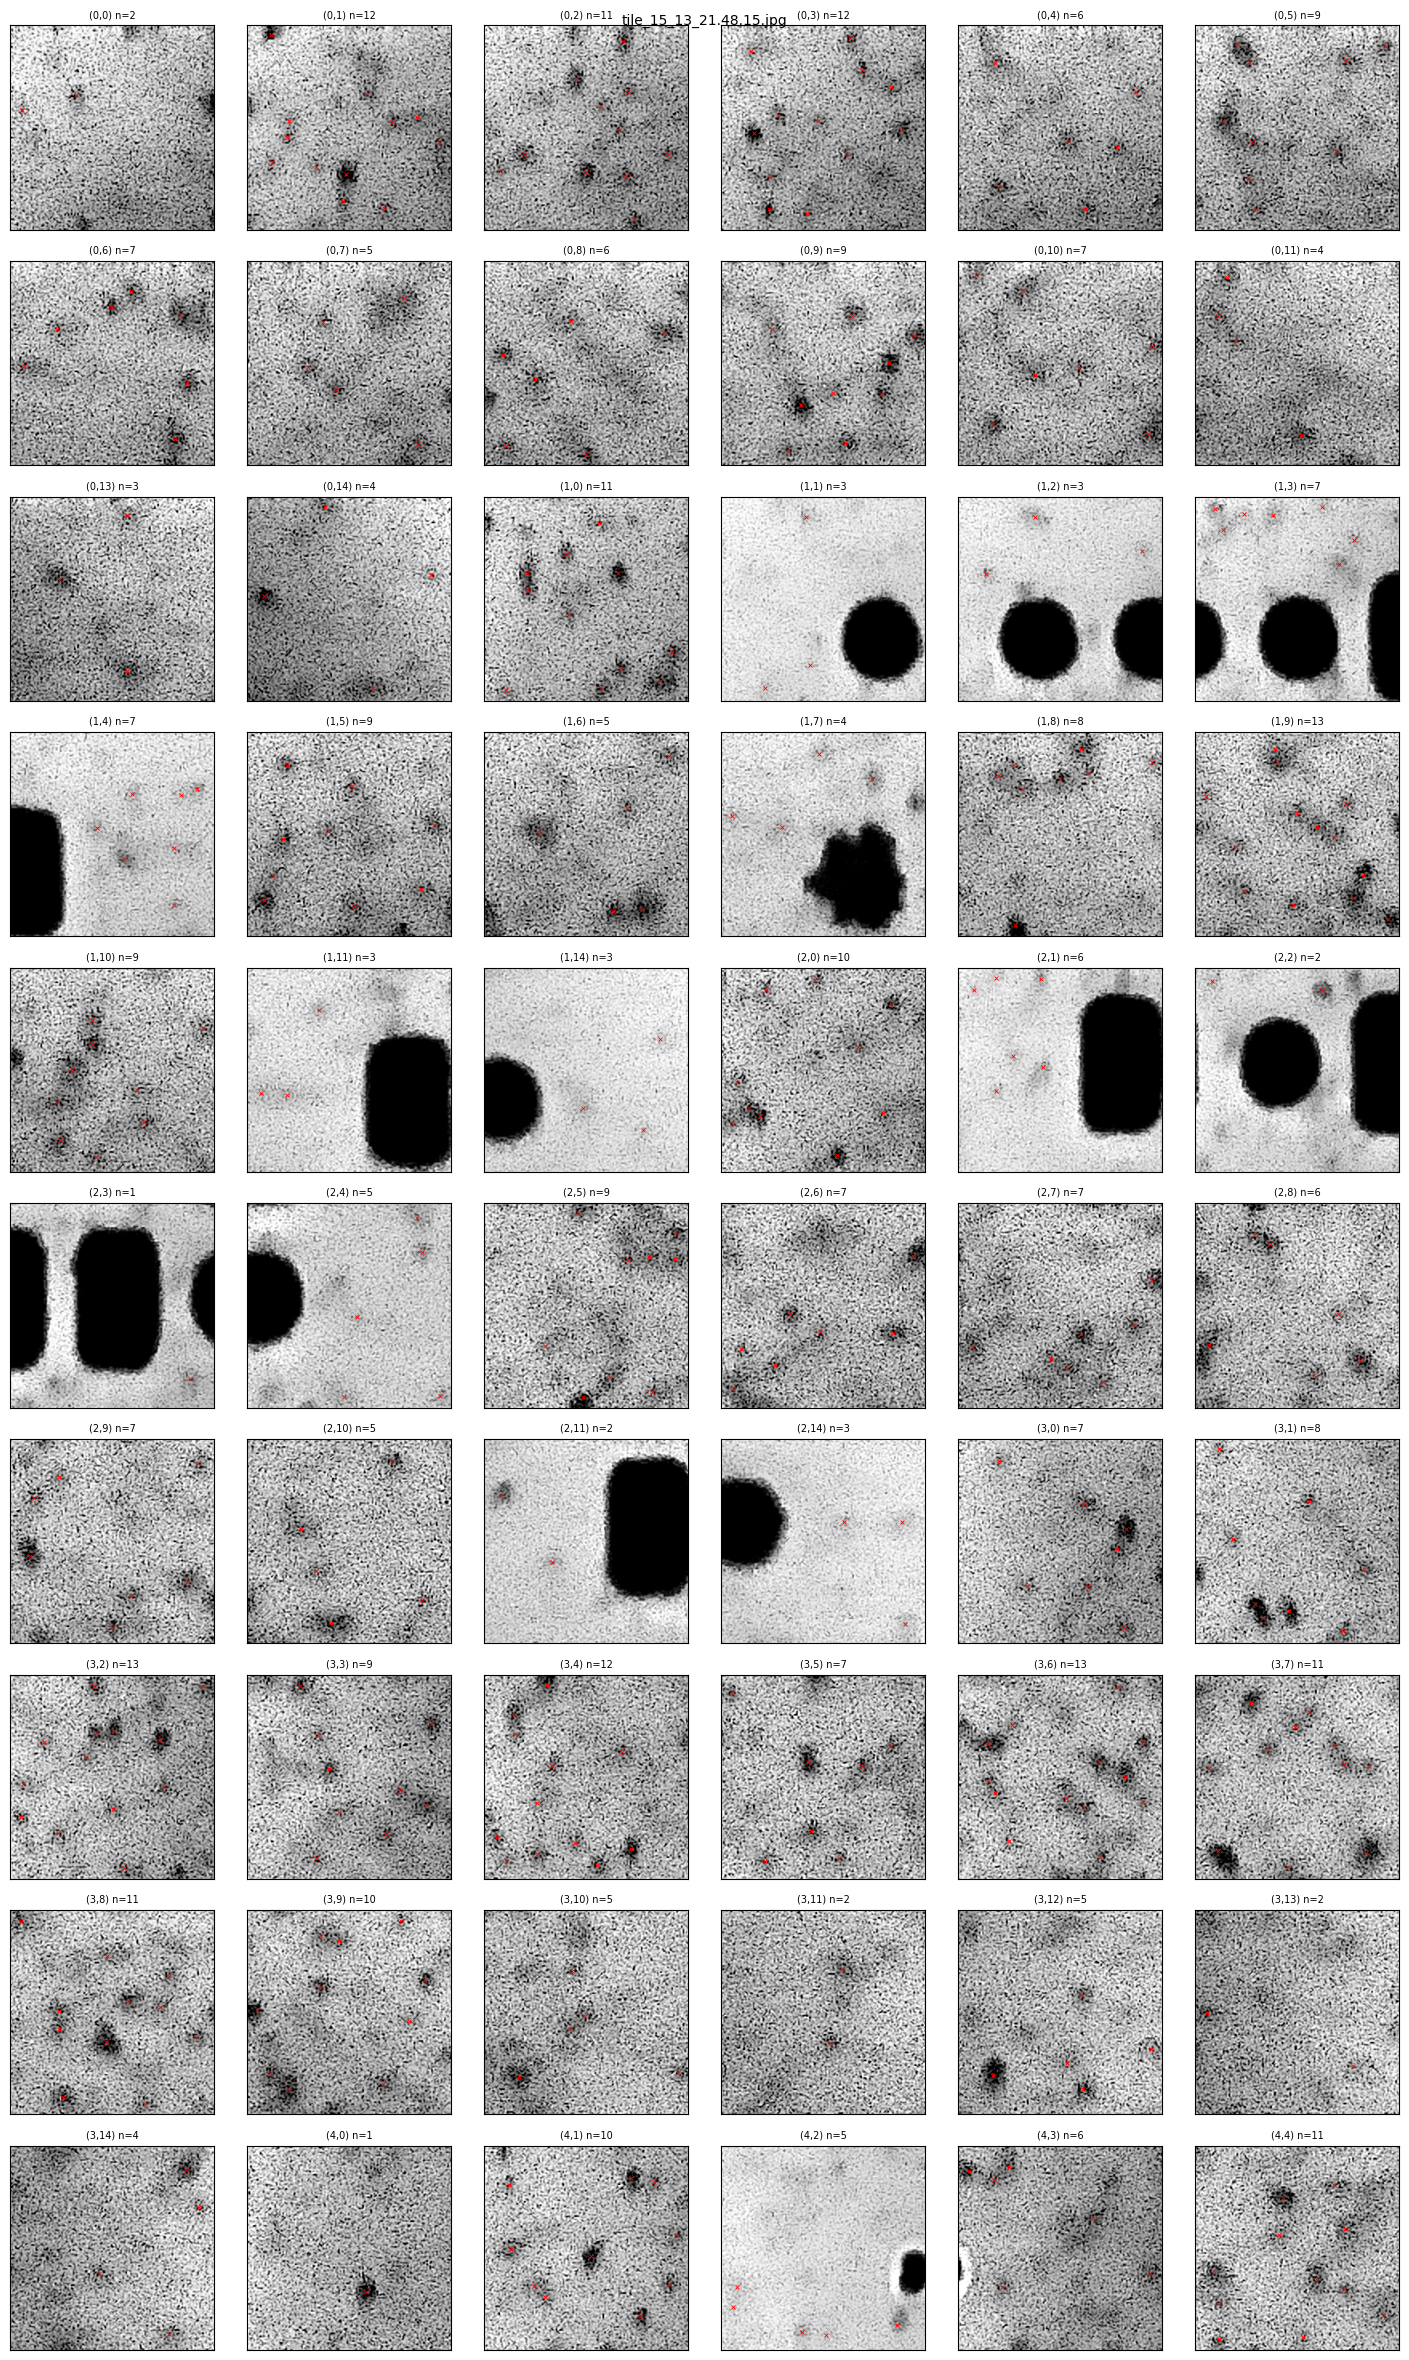

In [55]:
def debug_grid(model, device, path, p_threshold=DEFAULT_THRESHOLD,
               max_tiles=60, only_with_detections=True, cols=6,
               marker_size=8, marker_lw=0.6):
    """Grid of native 256x256 tiles with detection x's overlaid.

    only_with_detections=True  -> only show tiles where the model fired
    max_tiles                   -> hard cap on tiles shown (oldest tiles first)
    """
    img = load_real_native(path)
    h, w = img.shape
    n_ty = h // NATIVE_WINDOW[0]
    n_tx = w // NATIVE_WINDOW[1]

    panels = []  # (ti, tj, native_tile, cx_native, cy_native)
    with torch.no_grad():
        for i in range(n_ty):
            for j in range(n_tx):
                native = img[i*NATIVE_WINDOW[0]:(i+1)*NATIVE_WINDOW[0],
                             j*NATIVE_WINDOW[1]:(j+1)*NATIVE_WINDOW[1]]
                raw = downsample_image(native)
                norm = normalize_tile(raw)
                forbidden = compute_forbidden_mask_fast(raw)
                x_in = torch.from_numpy(norm).float().unsqueeze(0).unsqueeze(0).to(device)
                p, _, _, _ = model(x_in, training=False)
                p_map = p[0, 0].cpu().numpy()
                binary = ((p_map > p_threshold) & ~forbidden).astype(np.uint8)
                n_labels, _, _, centroids = cv2.connectedComponentsWithStats(binary, 8)
                if n_labels > 1:
                    cx_native = centroids[1:, 0] * DOWNSCALE_FACTOR
                    cy_native = centroids[1:, 1] * DOWNSCALE_FACTOR
                else:
                    cx_native = cy_native = np.array([])
                if only_with_detections and len(cx_native) == 0:
                    continue
                panels.append((i, j, native, cx_native, cy_native))
                if len(panels) >= max_tiles:
                    break
            if len(panels) >= max_tiles:
                break

    if not panels:
        print("no tiles to show (no detections at this threshold)")
        return

    rows = (len(panels) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(2.4*cols, 2.4*rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (i, j, tile, cx, cy) in zip(axes, panels):
        ax.imshow(tile, cmap="gray",
                  vmin=np.percentile(tile, 1), vmax=np.percentile(tile, 99))
        if len(cx):
            ax.scatter(cx, cy, marker="x", color="red",
                       s=marker_size, lw=marker_lw)
        ax.set_title(f"({i},{j}) n={len(cx)}", fontsize=7)
        ax.set_xticks([]); ax.set_yticks([])
    for ax in axes[len(panels):]:
        ax.axis("off")
    plt.suptitle(os.path.basename(path), fontsize=10)
    plt.tight_layout()
    plt.show()

worst = df[df["threshold"] == DEFAULT_THRESHOLD] \
          .sort_values("n_detections", ascending=False).iloc[0]
print(worst["path"], "total n=", worst["n_detections"])

debug_grid(model, device, worst["path"],
           p_threshold=DEFAULT_THRESHOLD,
           max_tiles=60,                # cap on tiles in the grid
           only_with_detections=True,   # set False to also see clean tiles
           cols=6,
           marker_size=8, marker_lw=0.6)